# Table of Contents

1. [Project Overview](#Project-Overview)
2. [Dataset](#dataset)
3. [Model Architecture (From Scratch)](#Model-Architecture-From-Scratch)
4. [Baseline Implementation](#Baseline-Implementation)
5. [Optimization Techniques](#Optimization-Techniques)
6. [Evaluation Metrics](#Evaluation-Metrics)
7. [Ablation Study](#Ablation-Study)
    - [Learning Rate Comparisons](#Learning-Rate-Comparisons)
    - [Regularization](#Regularization)
        - [Effect of Dropout Probability](#Effect-of-Dropout-Probability)
        - [Effect of L2 Regularization Strength](#Effect-of-L2-Regularization-Strength)
    - [Effect of Optimization Algorithm](#Effect-of-Optimization-Algorithm)
    - [Effect of Adam Hyperparameters](#Effect-of-Adam-Hyperparameters)
8. [Final Model Configuration](#Final-Model-Configuration)
9. [Results and Discussion](#Results-and-Discussion)
10. [Conclusion](#Conclusion)

## Project Overview

This project implements a neural network from scratch to classify CIFAR-10 images.  
The objective is to achieve at least 75% test accuracy.  

An ablation study is conducted to evaluate:
- Learning rate decay strategies  
- Regularization methods (L2, Dropout)  
- Optimization algorithms (SGD, Momentum, Adam)  
- Adam hyperparameter sensitivity  

## Dataset

In [1]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from util import get_device
from evaluations import train_model, plot_metrics
from model.model import Model

In [2]:
# CIFAR-10 normalization stats
cifar_mean = [0.485, 0.456, 0.406]
cifar_std  = [0.229, 0.224, 0.225]


# Training transforms (with augmentation + normalization)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])


# Test transforms (NO augmentation, but WITH normalization)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])


training_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=train_transform
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=test_transform
)


from torch.utils.data import DataLoader
batch_size = 128
train_loader = torch.utils.data.DataLoader(training_data, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

c:\Users\alexm\Documents\GitHub\CIFAR-10-Image-Classifier\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### Data Format & Batch Creation

In [3]:
image, label = training_data[0]
print("Image Shape: ", image.shape)
print("Label: ", label)

print("All Class Labels: \n", training_data.classes)

for images, labels in train_loader:
    print("images: [batch_size, channels, height, width]")
    print(images.shape)
    print("labels: [batch_size]")
    print(labels.shape)

    break


Image Shape:  torch.Size([3, 32, 32])
Label:  6
All Class Labels: 
 ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
images: [batch_size, channels, height, width]
torch.Size([128, 3, 32, 32])
labels: [batch_size]
torch.Size([128])


# Example images

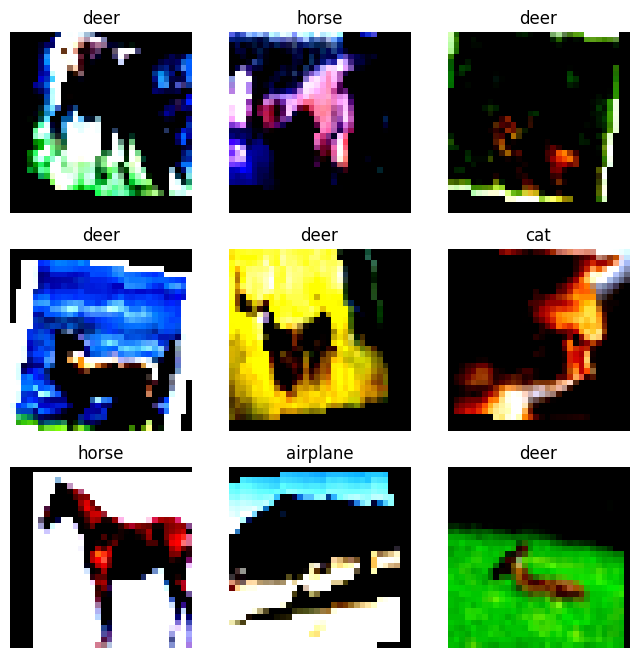

In [4]:
from util import show_random_images
show_random_images(training_data)


## Create model (Pytorch Implementation)

### Layer Creation

In [5]:
device = get_device()

NVIDIA CUDA detected
Set to use device: cuda


In [6]:
# torch.save(main_model.state_dict(), "cifar10_model_main.pth")

# Abalation Study

In [7]:
all_models = {}

def add_model(name, train_accs, test_accs, train_costs):
  all_models[name] = {
    "train_accs": train_accs,
    "test_accs": test_accs,
    "train_costs": train_costs
  }

## Base Model

Epoch 1: Loss 1.9691, Train 29.44%, Test 37.54%
Epoch 2: Loss 1.6644, Train 39.47%, Test 44.24%
Epoch 3: Loss 1.5422, Train 43.68%, Test 45.64%


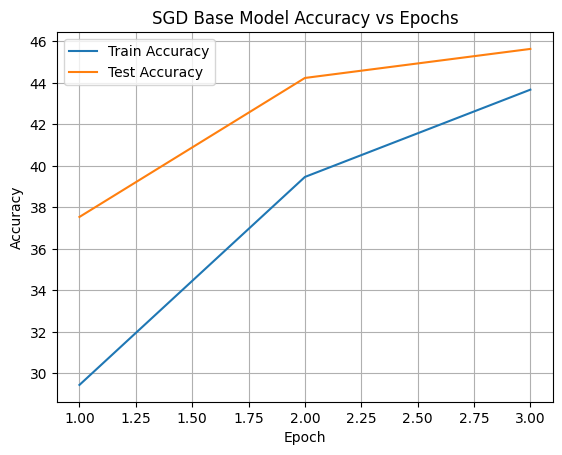

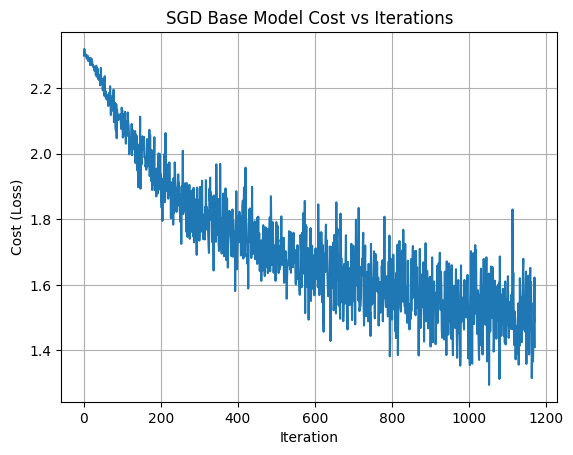

In [8]:
base_model, base_train_accs, base_test_accs, base_train_costs = train_model(
    model=Model(),
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=3,
    lr=0.01,
    optimizer_type="sgd",
    momentum=0,
    weight_decay=0.0,
    learn_rate_type=None
)
add_model("SGD Base", base_train_accs, base_test_accs, base_train_costs)

plot_metrics(
    train_accs=base_train_accs,
    test_accs=base_test_accs,
    costs=base_train_costs,
    title_prefix="SGD Base Model"
)

## Regularization

### L2 Regularization 

Epoch 1: Loss 1.6614, Train 38.57%, Test 51.99%
Epoch 2: Loss 1.3610, Train 50.39%, Test 59.98%
Epoch 3: Loss 1.2101, Train 56.32%, Test 63.27%
Epoch 1: Loss 1.6222, Train 40.36%, Test 54.61%
Epoch 2: Loss 1.3259, Train 51.69%, Test 57.29%
Epoch 3: Loss 1.1967, Train 56.71%, Test 64.20%
Epoch 1: Loss 1.6527, Train 39.01%, Test 50.55%
Epoch 2: Loss 1.3474, Train 50.88%, Test 60.28%
Epoch 3: Loss 1.2106, Train 56.40%, Test 64.28%
Epoch 1: Loss 1.6516, Train 39.35%, Test 49.87%
Epoch 2: Loss 1.3700, Train 50.01%, Test 58.33%
Epoch 3: Loss 1.2279, Train 55.56%, Test 61.64%
Epoch 1: Loss 1.6325, Train 39.61%, Test 51.48%
Epoch 2: Loss 1.3464, Train 50.86%, Test 56.86%
Epoch 3: Loss 1.2165, Train 56.35%, Test 61.73%


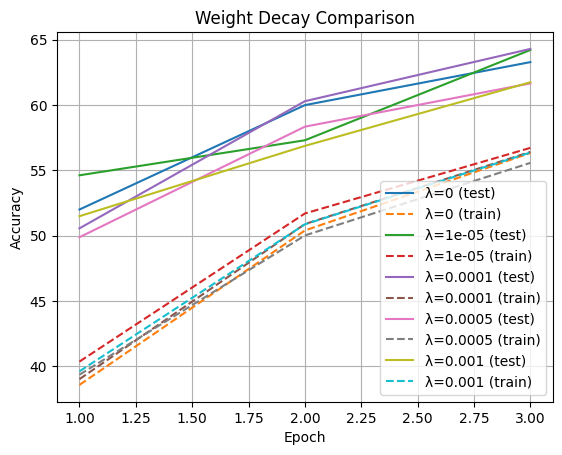

In [9]:
test_lambdas = [0, 1e-5, 1e-4, 5e-4, 1e-3]
models = {}
for i in range(len(test_lambdas)):
  lam = test_lambdas[i]
  model, train_accs, test_accs, train_costs = train_model(
      model=Model(),
      train_loader=train_loader,
      test_loader=test_loader,
      device=device,
      epochs=3,
      lr=0.01,
      optimizer_type="sgd",
      weight_decay=lam
  )
  models[lam] = {
      "model": model,
      "train_accs": train_accs,
      "test_accs": test_accs,
      "train_costs": train_costs
  }
  add_model(f"L2 λ={lam}", train_accs, test_accs, train_costs)
plt.figure()

for lam, data in models.items():
    epochs = range(1, len(data["train_accs"]) + 1)
    plt.plot(epochs, data["test_accs"], label=f"λ={lam} (test)")
    plt.plot(epochs, data["train_accs"], linestyle='--', label=f"λ={lam} (train)")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Weight Decay Comparison")
plt.legend()
plt.grid()
plt.show()

Based on the weight decay comparison the effects of λ for weight decay has minimal impact over 5 iterations. The best test accuracy was achieved by λ = .0005 while the best train accuracy was achieved by λ = .001. All λ resulted in a very similar train and test accuracy though all within 1% of eachother. This shows regularization doesn not influence performance in early training.

### Dropout (P = .3, .5, .7)

Epoch 1: Loss 1.6371, Train 39.76%, Test 53.49%
Epoch 2: Loss 1.3431, Train 51.01%, Test 58.41%
Epoch 3: Loss 1.2136, Train 56.43%, Test 62.28%
Epoch 1: Loss 1.6907, Train 37.52%, Test 52.07%
Epoch 2: Loss 1.4337, Train 47.49%, Test 56.17%
Epoch 3: Loss 1.3172, Train 52.09%, Test 61.87%
Epoch 1: Loss 1.7649, Train 34.18%, Test 47.57%
Epoch 2: Loss 1.5516, Train 42.77%, Test 51.36%
Epoch 3: Loss 1.4357, Train 47.73%, Test 58.30%
Epoch 1: Loss 1.8924, Train 29.01%, Test 42.18%
Epoch 2: Loss 1.7234, Train 36.01%, Test 48.28%
Epoch 3: Loss 1.6443, Train 38.95%, Test 52.09%


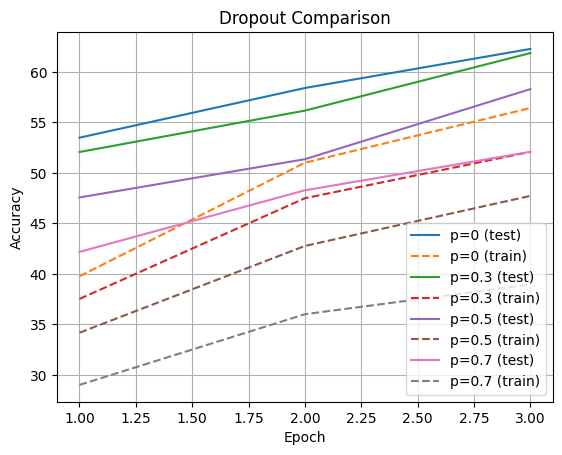

In [10]:
test_p = [0, .3, .5, .7]
models = {}
for i in range(len(test_p)):
    p = test_p[i]
    model, train_accs, test_accs, train_costs = train_model(
        model=Model(dropout_p=p),
        train_loader=train_loader,
        test_loader=test_loader,
        device=device,
        epochs=3,
        lr=0.01,
        optimizer_type="sgd",
        weight_decay=0
    )
    models[p] = {
      "model": model,
      "train_accs": train_accs,
      "test_accs": test_accs,
      "train_costs": train_costs
    }
    add_model(f"Dropout p={p}", train_accs, test_accs, train_costs)
plt.figure()

for p, data in models.items():
    epochs = range(1, len(data["train_accs"]) + 1)
    plt.plot(epochs, data["test_accs"], label=f"p={p} (test)")
    plt.plot(epochs, data["train_accs"], linestyle='--', label=f"p={p} (train)")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Dropout Comparison")
plt.legend()
plt.grid()
plt.show()

The comparison between dropout probabilities shows that increasing p reduces both training and test accuracy over 5 epochs. This is expected, as more neurons are randomly dropped during training, reducing the capacity of the model.

## Optimization Algorithms

### Exponential Decay

Epoch 1: Loss 1.6351, Train 39.83%, Test 50.84%
Epoch 2: Loss 1.3413, Train 51.25%, Test 57.63%
Epoch 3: Loss 1.2005, Train 56.64%, Test 61.81%


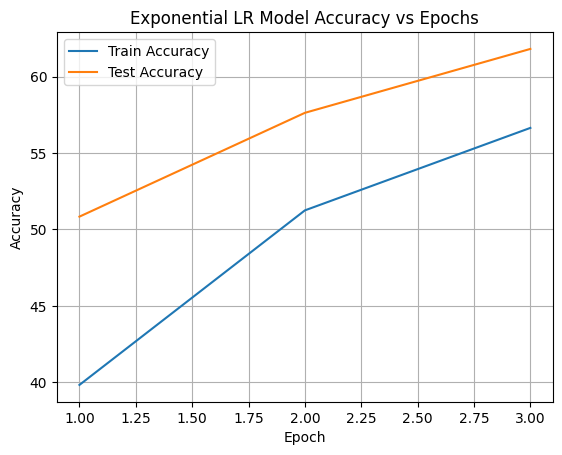

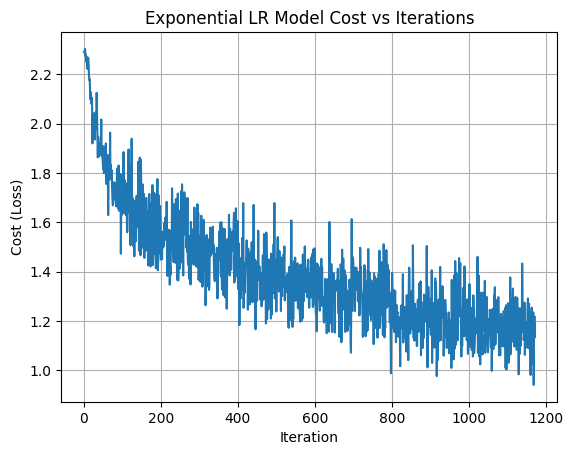

In [11]:
model, train_accs, test_accs, train_costs = train_model(
  model=Model(),
  train_loader=train_loader,
  test_loader=test_loader,
  device=device,
  epochs=3,
  lr=0.01,
  optimizer_type="sgd",
  learn_rate_type="exponential",
  weight_decay=0
)
plot_metrics(
    train_accs=train_accs,
    test_accs=test_accs,
    costs=train_costs,
    title_prefix="Exponential LR Model"
)
add_model(f"Exponential Decay", train_accs, test_accs, train_costs)

Adding exponential learning rate decay improves test accuracy by over 10% compared to baseline SGD. This suggests that reducing the learning rate helps the model converge better. However, this observation is based on a limited number of training epochs.

### Cosine Decay

In [ ]:
test_betas = [(0.9, 0.999), (0.8, 0.99), (0.7, 0.9)]

models = {}

for beta in test_betas:
    model, train_accs, test_accs, train_costs = train_model(
        model=Model(),
        train_loader=train_loader,
        test_loader=test_loader,
        device=device,
        epochs=3,
        lr=0.01,
        optimizer_type="sgd",
        learn_rate_type="cosine",
        betas=beta,
        weight_decay=0
    )

    models[beta] = {
        "model": model,
        "train_accs": train_accs,
        "test_accs": test_accs,
        "train_costs": train_costs
    }
    add_model(f"SGD + Cosine β1={beta[0]}, β2={beta[1]}", train_accs, test_accs, train_costs)

Epoch 1: Loss 1.6282, Train 40.25%, Test 54.83%
Epoch 2: Loss 1.3135, Train 52.29%, Test 58.05%
Epoch 3: Loss 1.1572, Train 58.20%, Test 62.43%


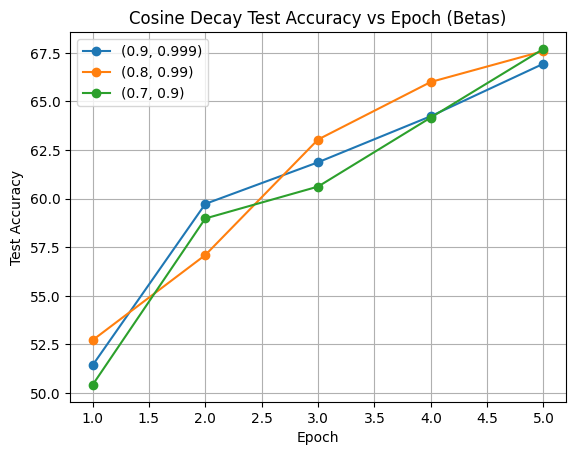

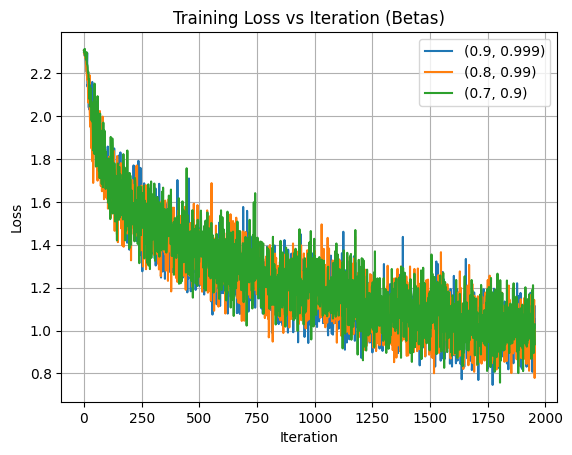

In [ ]:

# --- Accuracy Plot ---
plt.figure()

for beta, data in models.items():
    epochs = range(1, len(data["test_accs"]) + 1)
    plt.plot(epochs, data["test_accs"], marker='o', label=f"{beta}")

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Cosine Decay Test Accuracy vs Epoch (Betas)")
plt.legend()
plt.grid()
plt.show()


# --- Loss Plot ---
plt.figure()

for beta, data in models.items():
    # If stored as (iteration, loss)
    add_model(f"Cosine β={beta}", data["train_accs"], data["test_accs"], data["train_costs"])
    if isinstance(data["train_costs"][0], tuple):
        iterations, losses = zip(*data["train_costs"])
        plt.plot(iterations, losses, label=f"{beta}")
    else:
        # If it's just a list of losses per step
        plt.plot(data["train_costs"], label=f"{beta}")

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss vs Iteration (Betas)")
plt.legend()
plt.grid()
plt.show()

Based on the plots over 5 iterations it is observed that the best performing configuration for test accuracy is beta1 = .7 and beta2 = .9. The difference between betas seems to have minimal impact over a small training though as they all finish with a train/test accuracy within 1% of each other and a steady increase of accuracy as epochs increase.

### Gradient Descent With Momentum

Epoch 1: Loss 1.6250, Train 39.78%, Test 49.86%
Epoch 2: Loss 1.3269, Train 51.50%, Test 61.13%
Epoch 3: Loss 1.2018, Train 56.80%, Test 63.03%
Epoch 4: Loss 1.1121, Train 60.03%, Test 63.85%
Epoch 5: Loss 1.0456, Train 62.83%, Test 67.38%


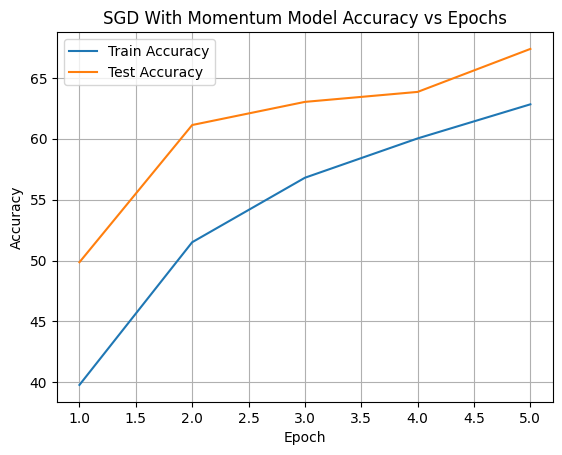

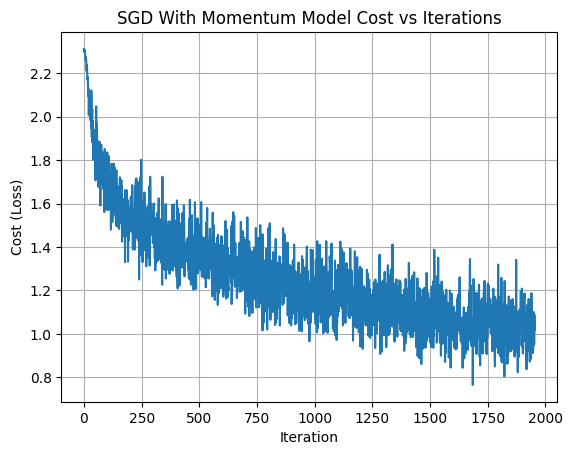

In [ ]:
model, train_accs, test_accs, train_costs = train_model(
  model=Model(),
  train_loader=train_loader,
  test_loader=test_loader,
  device=device,
  epochs=3,
  lr=0.01,
  optimizer_type="sgd",
  momentum=.9,
  weight_decay=0
)
add_model("SGD + Momentum (0.9)", train_accs, test_accs, train_costs)
plot_metrics(
    train_accs=train_accs,
    test_accs=test_accs,
    costs=train_costs,
    title_prefix="SGD With Momentum Model"
)

By simply adding momentum to SGD test accuracy increases by over 10% compared to baseline SGD. This suggests that momentum helps accelerate convergence. However, this observation is based on a limited number of training epochs, so the impact may differ in longer training scenarios.

### Adam - Beta1 & Beta2

In [ ]:
test_betas = [(0.9, 0.999), (0.8, 0.99), (0.7, 0.9)]

models = {}

for beta in test_betas:
  model, train_accs, test_accs, train_costs = train_model(
    model=Model(),
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=3,
    lr=0.01,
    optimizer_type="adam",
    betas=beta,
    weight_decay=0
  )

  models[beta] = {
    "model": model,
    "train_accs": train_accs,
    "test_accs": test_accs,
    "train_costs": train_costs
  }
  add_model(f"Adam β1={beta[0]}, β2={beta[1]}", train_accs, test_accs, train_costs)

Epoch 1: Loss 2.1022, Train 22.97%, Test 34.65%
Epoch 2: Loss 1.6578, Train 34.17%, Test 41.43%
Epoch 3: Loss 1.5045, Train 41.10%, Test 44.86%
Epoch 1: Loss 2.0863, Train 20.57%, Test 25.80%
Epoch 2: Loss 1.7603, Train 29.14%, Test 35.52%
Epoch 3: Loss 1.5148, Train 39.94%, Test 47.93%
Epoch 1: Loss 2.0790, Train 23.51%, Test 29.27%
Epoch 2: Loss 1.6861, Train 32.41%, Test 36.35%
Epoch 3: Loss 1.5839, Train 37.31%, Test 42.84%


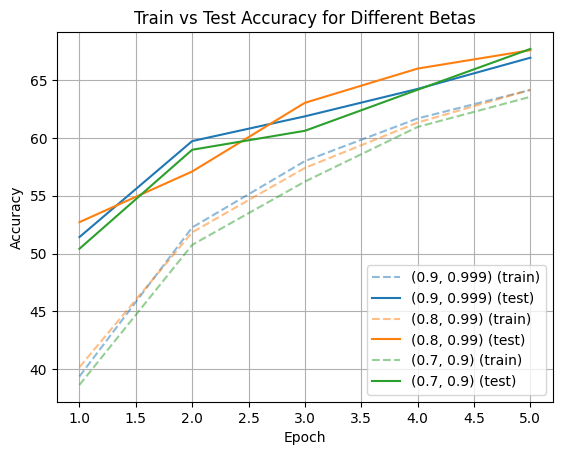

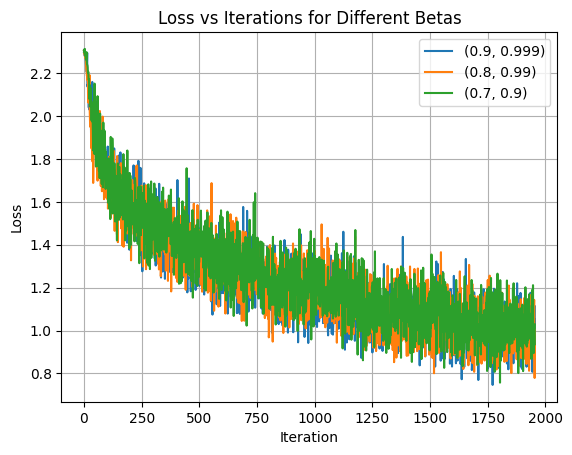

In [ ]:
# get default color 
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# --- Accuracy Plot ---
plt.figure()

for i, (beta, data) in enumerate(models.items()):
    epochs = range(1, len(data["train_accs"]) + 1)
    color = colors[i % len(colors)]
    
    # train = lighter 
    plt.plot(epochs, data["train_accs"],
        linestyle='--', color=color, alpha=0.5,
        label=f"{beta} (train)")
    
    # test = solid + full color
    plt.plot(epochs, data["test_accs"],
        linestyle='-', color=color, alpha=1.0,
        label=f"{beta} (test)")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy for Different Betas")
plt.legend()
plt.grid()
plt.show()


# --- Loss Plot ---
plt.figure()

for i, (beta, data) in enumerate(models.items()):
    iterations, losses = zip(*data["train_costs"])
    color = colors[i % len(colors)]
    
    plt.plot(iterations, losses, color=color, label=f"{beta}")

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss vs Iterations for Different Betas")
plt.legend()
plt.grid()
plt.show()

Based on the plots over 5 iterations it is observed that the best performing configuration for test accuracy is beta1 = .7 and beta2 = .9. The difference between betas seems to have minimal impact over a small training though as they all finish with a train/test accuracy within 1% of each other and a steady increase of accuracy as epochs increase.

In [ ]:
# --- Main Model ---
main_model, main_train_accs, main_test_accs, main_train_costs = train_model(
    model=Model(),
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=3,
    lr=0.001,
    optimizer_type="adam",
    weight_decay=1e-4,
    learn_rate_type="cosine",
    gamma=0.9
)
add_model("Adam Final", main_train_accs, main_test_accs, main_train_costs)

# Plot main model
plot_metrics(
    train_accs=main_train_accs,
    test_accs=main_test_accs,
    costs=main_train_costs,
    title_prefix="Final Adam + Cosine Model"
)

Selected Models:
SGD Base


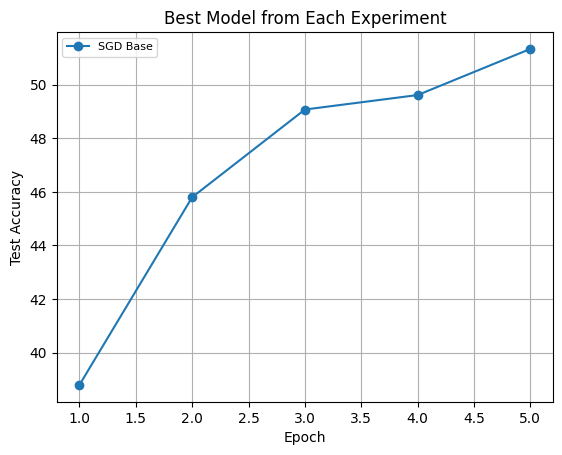

In [ ]:
# --- Select BEST models from each experiment ---

best_models = {}

def get_best_model(prefix):
    candidates = {k: v for k, v in all_models.items() if prefix in k}
    if not candidates:
        return None
    return max(candidates.items(), key=lambda x: max(x[1]["test_accs"]))

# Pick best from each category
categories = [
    "SGD Base",
    "L2",
    "Dropout",
    "SGD + Cosine",
    "Adam β",
    "SGD + Momentum",
    "Exponential",
    "Adam Final"
]

for cat in categories:
    result = get_best_model(cat)
    if result:
        name, data = result
        best_models[name] = data

print("Selected Models:")
for name in best_models:
    print(name)
plt.figure()

for name, data in best_models.items():
    epochs = range(1, len(data["test_accs"]) + 1)
    plt.plot(epochs, data["test_accs"], marker='o', label=name)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Best Model from Each Experiment")
plt.legend(fontsize=8)
plt.grid()
plt.show()